# 2-stage coefficient-to-mask pipeline

This notebook trains the cascaded coefficient-to-mask system at training noise levels `0.0`, `0.001`, `0.0025`, `0.005`, and `0.01`. Each model is stored under `output/two_stage/train_sigma...` and evaluated at every test noise level under nested `test_sigma...` folders. Predicted-coefficient IoU is the deployed metric; true-coefficient IoU remains diagnostic only.

Stage 1 uses MSE regression with hidden layers `(256, 512, 256)`. Stage 2 uses a coordinate-convolution decoder with BCE+Dice, rectangle edge weighting, and predicted-coefficient augmentation. Validation and official test data remain clean during training.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import torch

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from config import Stage1ModelConfig, Stage2ModelConfig, StageTrainingConfig, TwoStageRunConfig, TwoStageStackConfig
from datasets import build_two_stage_datasets
from experiments import evaluate_noise_sweep, layer_table, load_two_stage_predictor, parameter_count, save_noise_results, sigma_label
from experiments.notebook import plot_history, plot_noise_curve, plot_shape_curves
from final_models.two_stage import run_two_stage
from models import Stage1Regressor
from pipeline.run import _build_stage2_model

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT = ROOT / 'output' / 'two_stage'
OUTPUT.mkdir(parents=True, exist_ok=True)
TRAIN_SIGMAS = (0.0, 0.001, 0.0025, 0.005, 0.01)
TEST_SIGMAS = TRAIN_SIGMAS
RUN_TRAINING = False

def make_config(train_sigma):
    train_dir = OUTPUT / f'train_sigma{sigma_label(train_sigma)}'
    stage1 = Stage1ModelConfig(hidden_layer_sizes=(256, 512, 256), dropout_rates=(0.2, 0.2, 0.2), training=StageTrainingConfig(epochs=200, batch_size=64, learning_rate=0.0005, validation_frequency=20, verbose=False, early_stopping_patience=20, min_epochs=40, min_improvement=0.001, lr_drop_factor=0.5, lr_drop_period=60, weight_decay=0.0001, gradient_clip_norm=1.0, loss_type='mse'))
    stage2 = Stage2ModelConfig(hidden_layer_sizes=(512, 1024), dropout_rates=(0.1, 0.1), model_type='coord_conv_decoder', latent_grid_size=16, latent_channels=160, decoder_channels=(160, 128, 96, 64, 32), use_rectangle_edge_weighting=True, use_foreground_pos_weight=False, rectangle_edge_weight=4.0, rectangle_edge_width=3, edge_weight_mode='rectangle', annulus_edge_weight=1.0, annulus_edge_width=3, training=StageTrainingConfig(epochs=170, batch_size=96, learning_rate=0.0005, validation_frequency=60, verbose=False, early_stopping_patience=25, min_epochs=50, min_improvement=0.001, lr_drop_factor=0.5, lr_drop_period=80, weight_decay=0.00025, gradient_clip_norm=0.8, loss_type='bce_dice', dice_loss_weight=1.0, dice_smooth=1.0))
    return TwoStageRunConfig(N=10, training_samples=20_000, validation_samples=2_000, test_samples=1_000, noise_sigma=train_sigma, noise_mode='absolute', seed=42, training_noise_replicas=2, use_validation_threshold_sweep=True, training_shape_weights=(('rectangle', 0.25), ('two_circles', 0.45), ('annulus', 0.10), ('ellipse', 0.15), ('circle', 0.05)), stage2_predicted_coefficient_augmentation_copies=2, stage2_predicted_coefficient_noise_scale=0.5, stage2_include_gradient_features=False, model=TwoStageStackConfig(stage1=stage1, stage2=stage2), output_dir=train_dir)

stage1_check = Stage1Regressor(input_dim=22, output_dim=22, hidden_dims=(256, 512, 256), dropout_rates=(0.2, 0.2, 0.2))
print('Stage 1 parameters:', parameter_count(stage1_check))
print('Stage 2 parameters:', parameter_count(_build_stage2_model(make_config(0.001))))
layer_table(stage1_check, torch.zeros(2, 22)).to_csv(OUTPUT / 'stage1_architecture.csv', index=False)

Stage 1 parameters: {'total': 274454, 'trainable': 274454}
Stage 2 parameters: {'total': 43121603, 'trainable': 43121603}



=== training sigma=0 ===


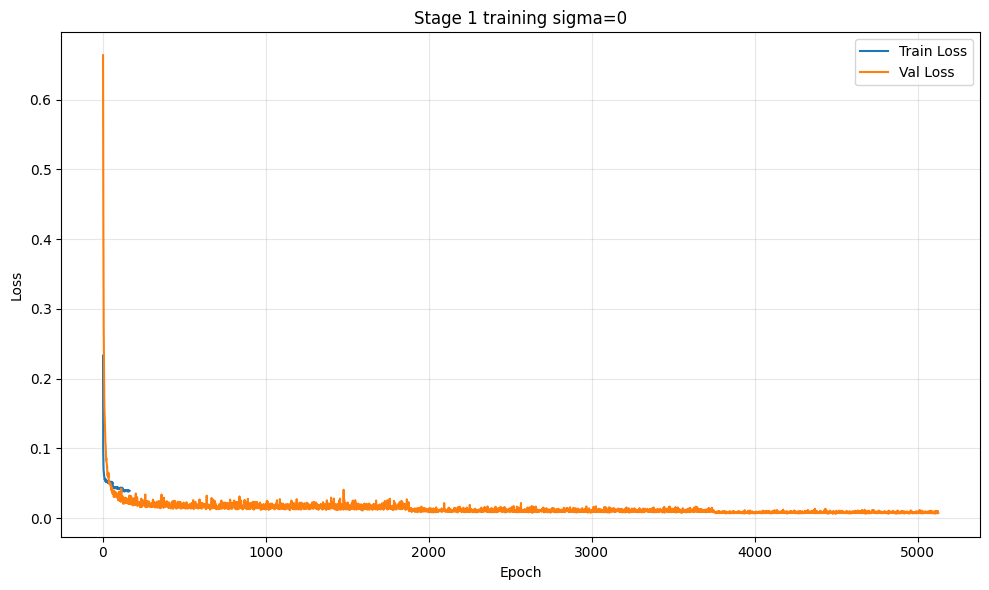

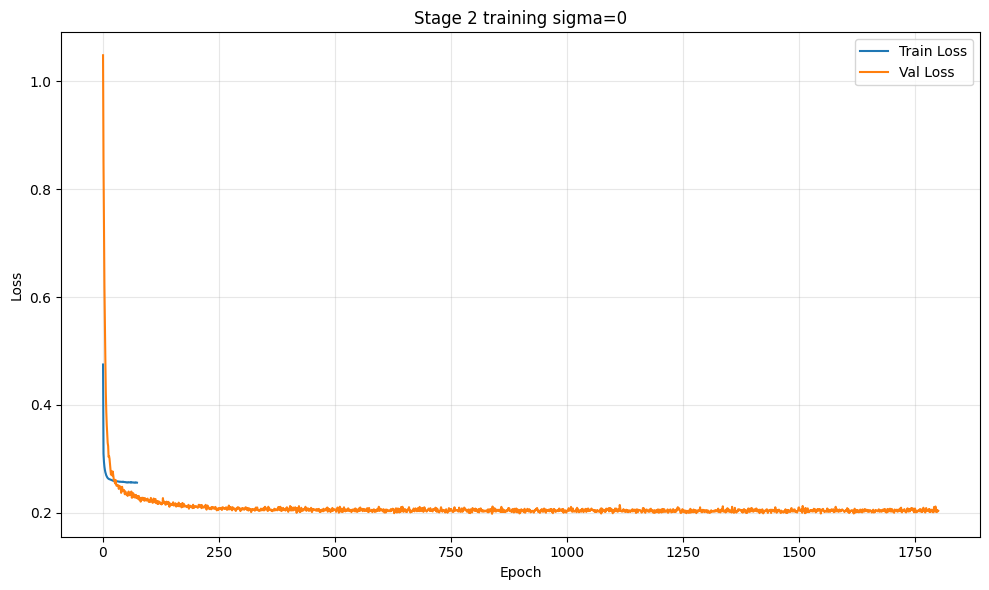

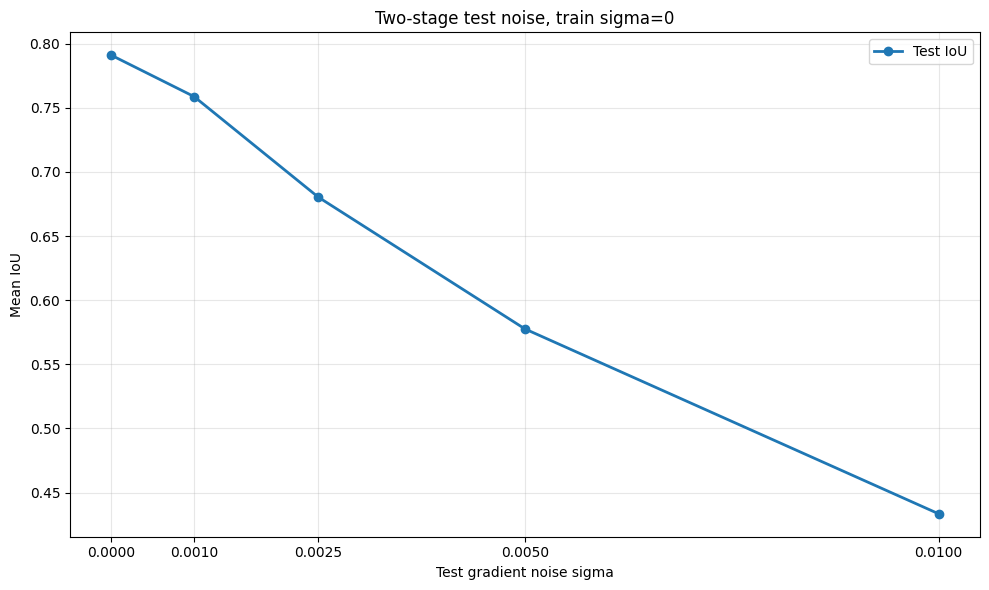

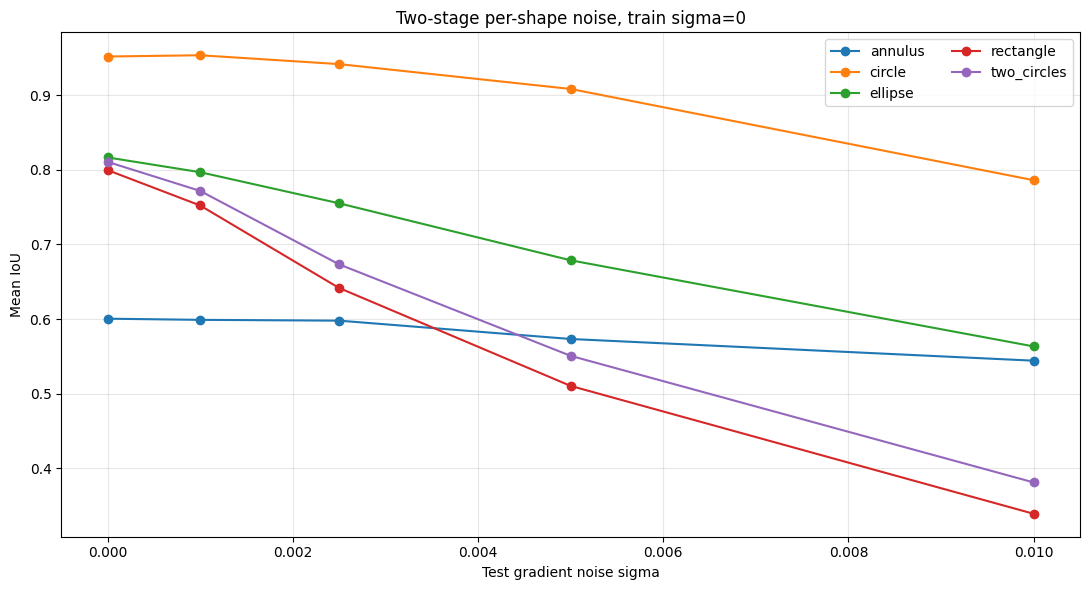


=== training sigma=0.001 ===


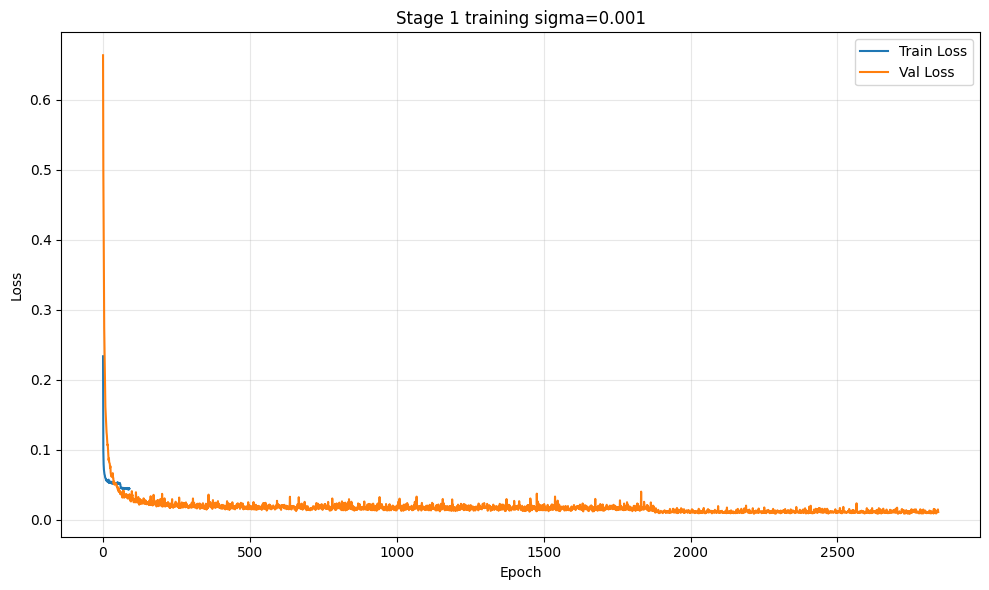

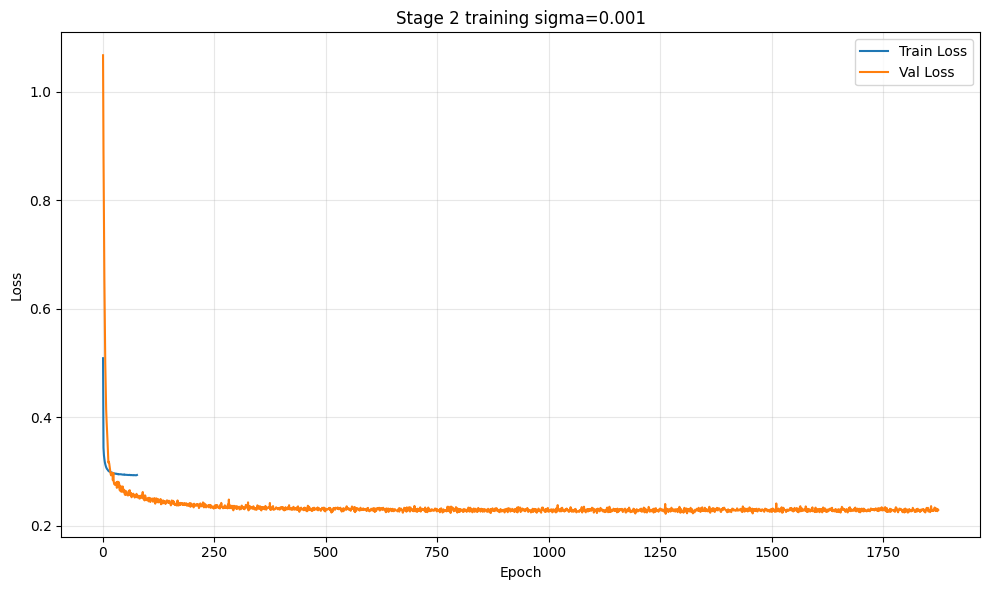

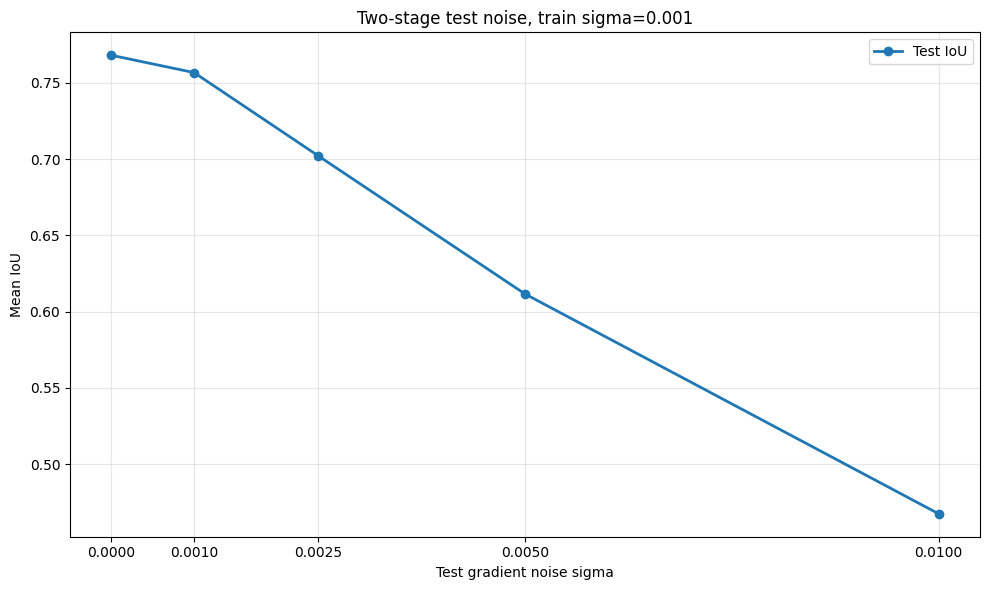

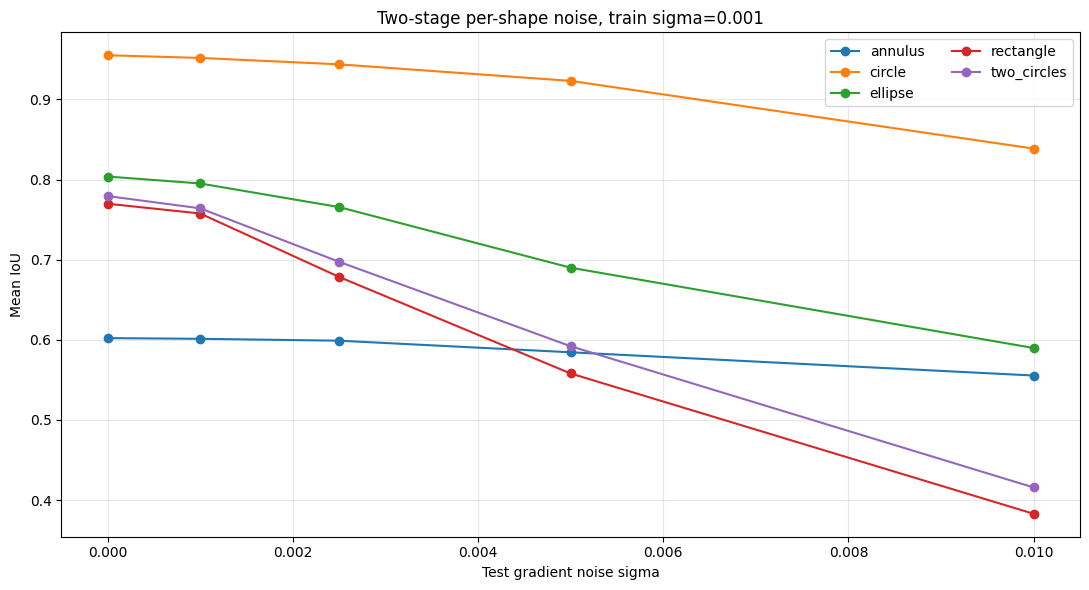


=== training sigma=0.0025 ===


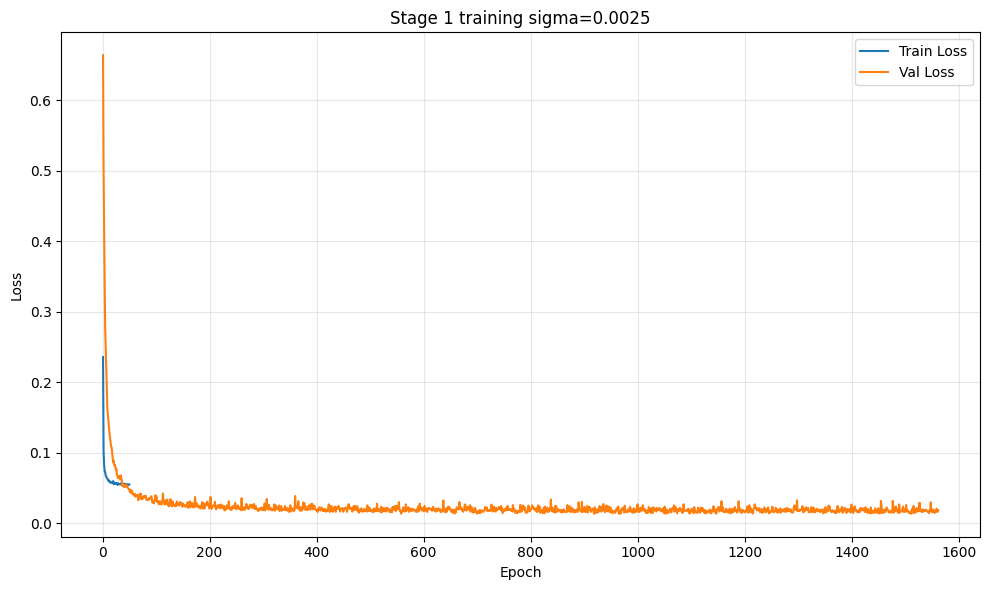

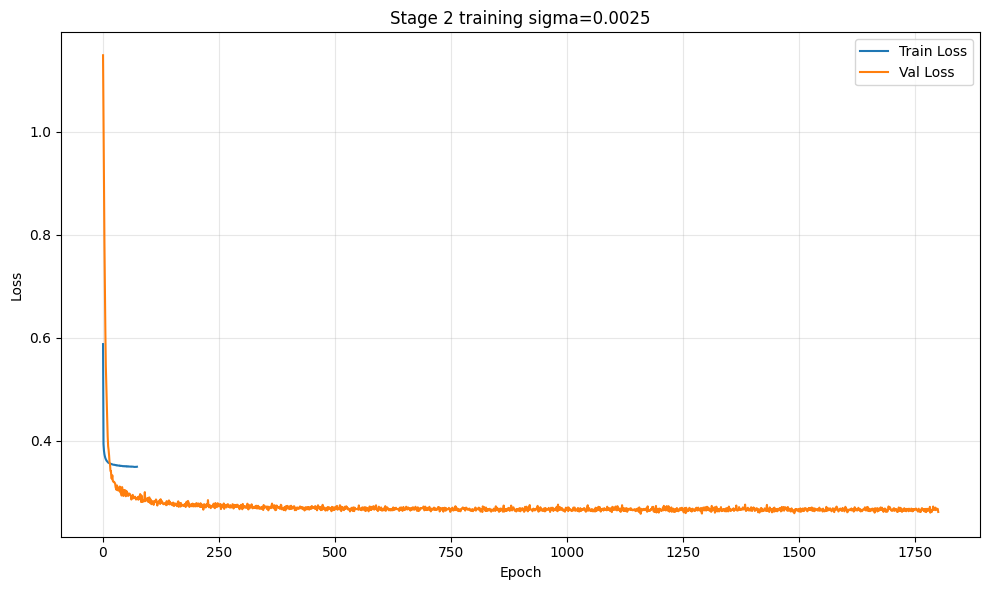

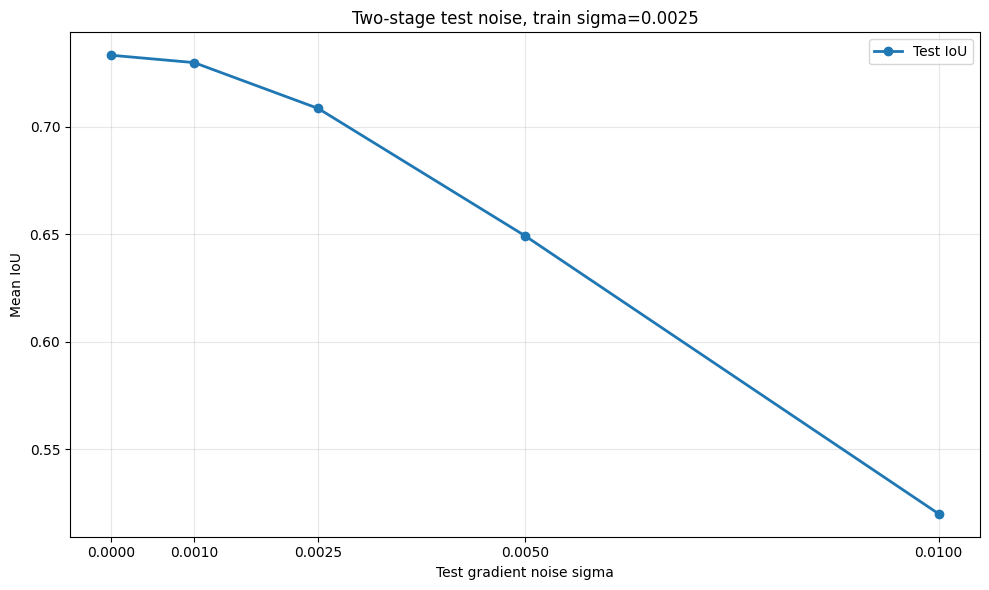

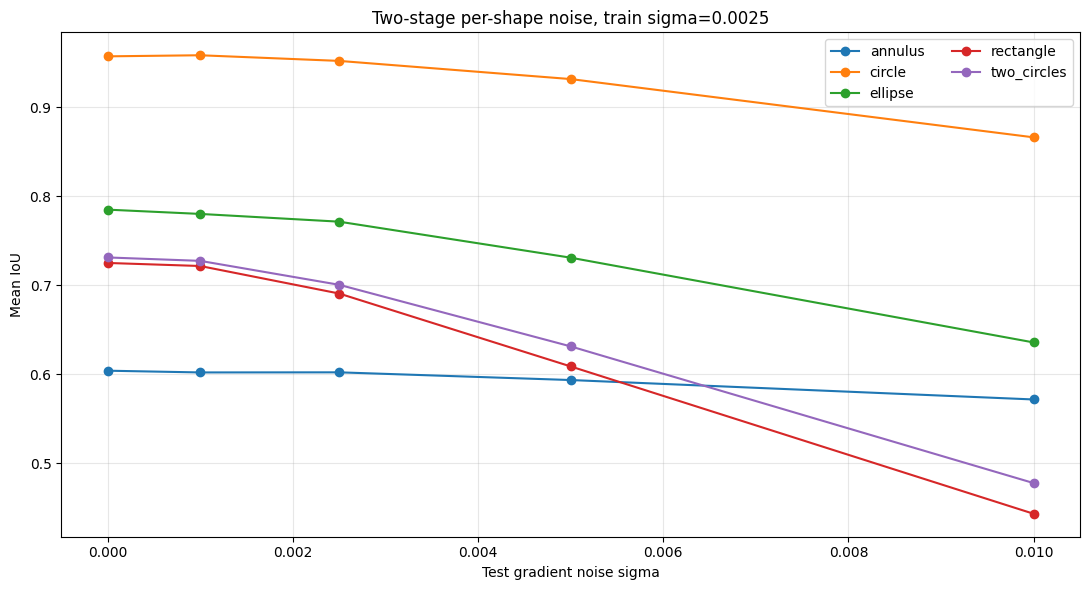


=== training sigma=0.005 ===


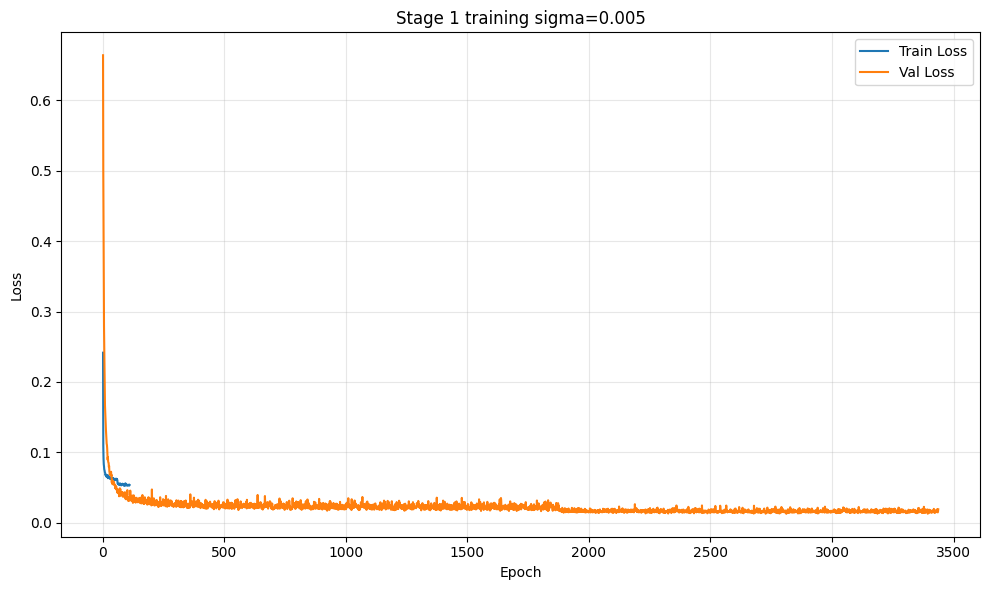

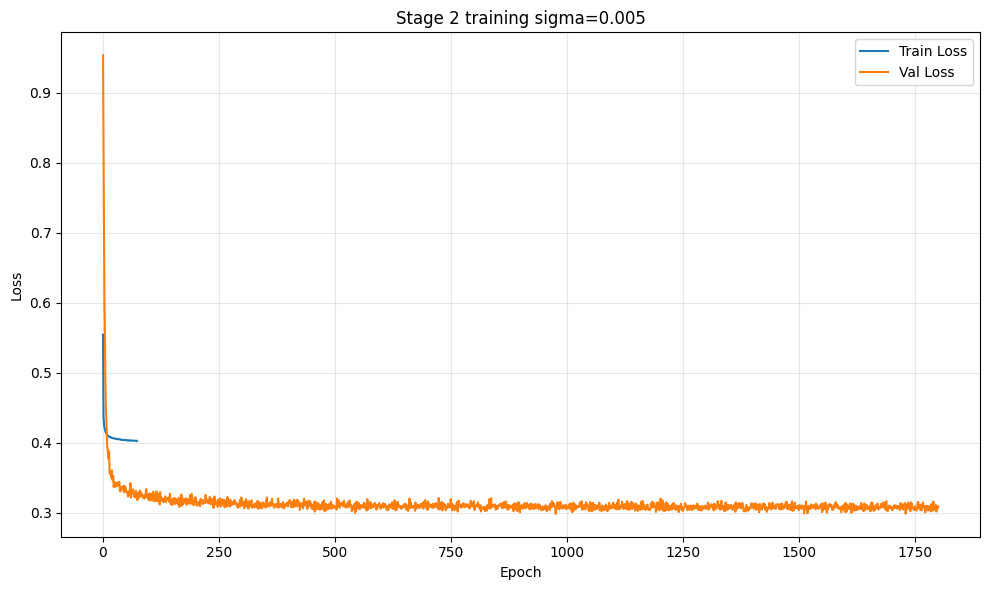

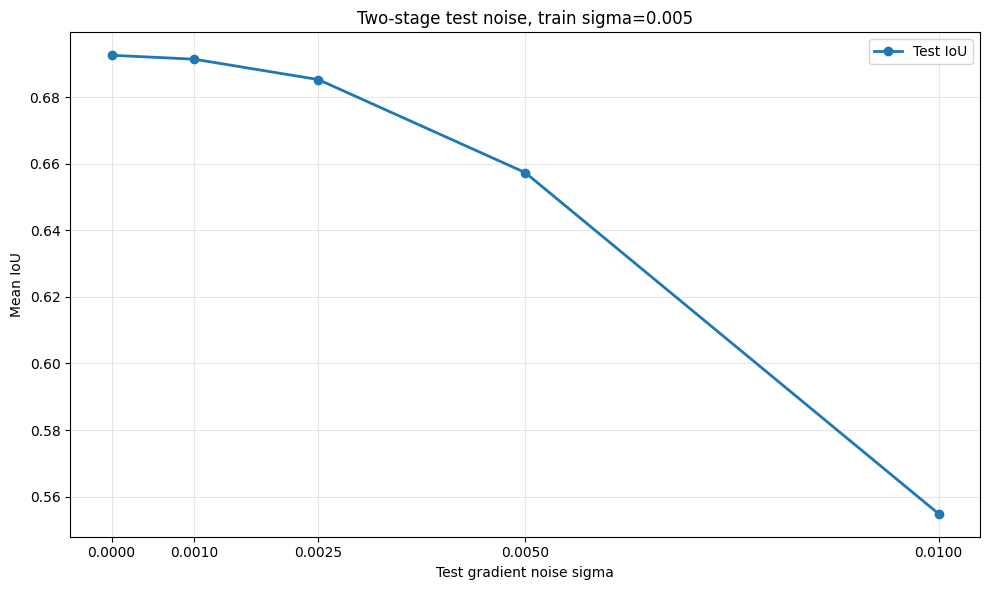

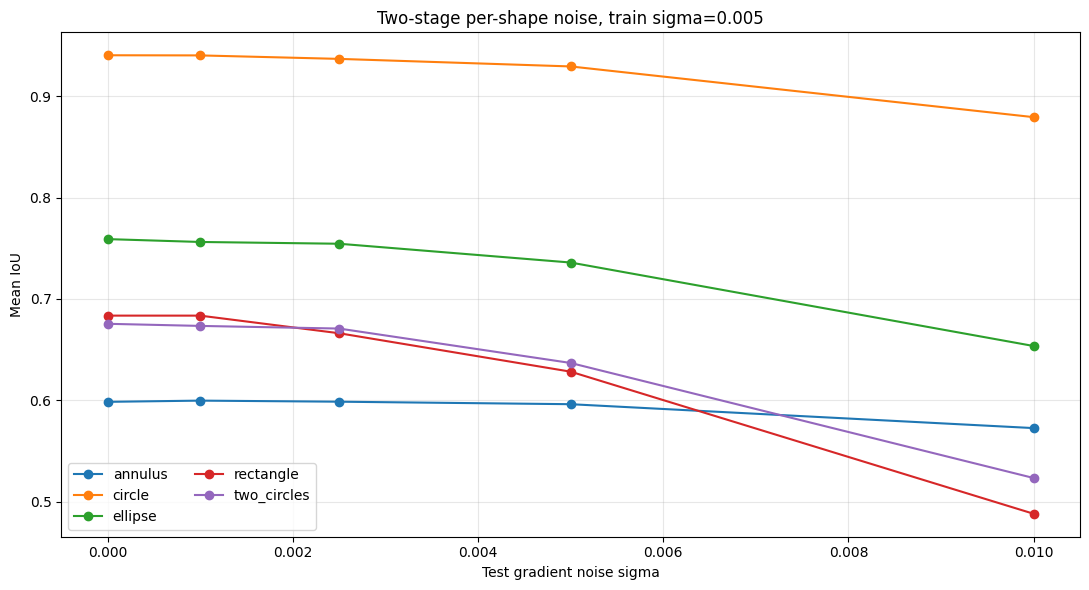


=== training sigma=0.01 ===


In [ ]:
comparison_rows = []
for train_sigma in TRAIN_SIGMAS:
    config = make_config(train_sigma)
    train_dir = config.output_dir
    summary_path = config.run_output_dir / 'summary.json'
    should_train = RUN_TRAINING or not summary_path.exists()
    print(f'\n=== training sigma={train_sigma:g} ===')
    summary = run_two_stage(config, device=DEVICE) if should_train else json.loads(summary_path.read_text(encoding='utf-8'))
    bundle = build_two_stage_datasets(config)
    predict_logits, summary = load_two_stage_predictor(config.output_dir, config, DEVICE)
    threshold = float(summary['threshold_summary']['selected_threshold'])
    overall, by_shape = evaluate_noise_sweep(predict_logits, bundle.test.gradient_data, bundle.test.masks, bundle.test.shape_types, threshold, noise_levels=TEST_SIGMAS, seed=42)
    save_noise_results(overall, by_shape, train_dir, stem='test_noise_robustness')
    plot_history(summary['stage1_history'], train_dir / 'stage1_training_curves.png', f'Stage 1 training sigma={train_sigma:g}')
    plot_history(summary['stage2_history'], train_dir / 'stage2_training_curves.png', f'Stage 2 training sigma={train_sigma:g}')
    plot_noise_curve(overall, train_dir / 'test_noise_curve.png', f'Two-stage test noise, train sigma={train_sigma:g}')
    plot_shape_curves(by_shape, train_dir / 'test_noise_by_shape.png', f'Two-stage per-shape noise, train sigma={train_sigma:g}')
    clean = overall[overall['noise_sigma'] == 0.0].iloc[0]
    comparison_rows.append({'train_sigma': train_sigma, 'clean_predicted_test_iou': clean['mean_iou'], 'clean_pixel_accuracy': clean['pixel_accuracy'], 'threshold': threshold})
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(OUTPUT / 'training_noise_comparison.csv', index=False)
display(comparison)

Example artifact paths:

`output/two_stage/train_sigma001/test_sigma000/metrics.csv`
`output/two_stage/train_sigma001/test_sigma005/metrics_by_shape.csv`

The `train_sigma...` directory also contains model weights, datasets, summaries, and training curves.